# 🛍️ Ecommerce LLM Fine-Tuning — Customer Support Assistant

End-to-end pipeline: download data → explore → clean → format → **QLoRA fine-tune**
`Llama-3.2-1B-Instruct` → evaluate → save adapter & merged model.

**Runs entirely on Google Colab Free (T4 GPU)** using open-source tools only:
Unsloth, Transformers, PEFT, TRL, Accelerate, BitsAndBytes.

> 💡 Runtime → Change runtime type → **T4 GPU** before running.


## Section 1 — Install Dependencies

Install all required packages, mount Google Drive (optional, for persistence), and set a reproducibility seed.

In [4]:
%%capture
# Core fine-tuning stack (Unsloth pulls in compatible torch/xformers automatically on Colab)
!pip install -U "unsloth" "unsloth_zoo"
!pip install -U "transformers>=4.42.0" "trl>=0.9.4" "peft>=0.11.0" "accelerate>=0.31.0"
!pip install -U "bitsandbytes>=0.43.1" "datasets>=2.19.0" "sentencepiece"
!pip install -U "evaluate" "rouge_score" "sacrebleu" "nltk"
!pip install -U "pandas" "numpy" "matplotlib" "scikit-learn"

In [5]:
# Cell 1
!pip install -U unsloth unsloth_zoo
!pip install -U transformers trl peft accelerate
!pip install -U bitsandbytes datasets evaluate rouge_score sacrebleu

  Using cached datasets-4.3.0-py3-none-any.whl.metadata (18 kB)
  Using cached transformers-5.5.0-py3-none-any.whl.metadata (32 kB)
  Using cached trl-0.24.0-py3-none-any.whl.metadata (11 kB)
Using cached datasets-4.3.0-py3-none-any.whl (506 kB)
Using cached transformers-5.5.0-py3-none-any.whl (10.2 MB)
Using cached trl-0.24.0-py3-none-any.whl (423 kB)
  Attempting uninstall: datasets
    Found existing installation: datasets 5.0.0
    Uninstalling datasets-5.0.0:
      Successfully uninstalled datasets-5.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.12.1
    Uninstalling transformers-5.12.1:
      Successfully uninstalled transformers-5.12.1
  Attempting uninstall: trl
    Found existing installation: trl 1.7.0
    Uninstalling trl-1.7.0:
      Successfully uninstalled trl-1.7.0


  Using cached transformers-5.12.1-py3-none-any.whl.metadata (33 kB)
  Using cached trl-1.7.0-py3-none-any.whl.metadata (11 kB)
  Using cached datasets-5.0.0-py3-none-any.whl.metadata (23 kB)
Using cached transformers-5.12.1-py3-none-any.whl (11.2 MB)
Using cached trl-1.7.0-py3-none-any.whl (838 kB)
Using cached datasets-5.0.0-py3-none-any.whl (555 kB)
  Attempting uninstall: datasets
    Found existing installation: datasets 4.3.0
    Uninstalling datasets-4.3.0:
      Successfully uninstalled datasets-4.3.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.5.0
    Uninstalling transformers-5.5.0:
      Successfully uninstalled transformers-5.5.0
  Attempting uninstall: trl
    Found existing installation: trl 0.24.0
    Uninstalling trl-0.24.0:
      Successfully uninstalled trl-0.24.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency co

### ⚠️ Restart Runtime

After installing the packages above, a `RuntimeError` regarding `numpy` might occur, indicating that `numpy` was upgraded mid-session. To resolve this, you need to **restart your runtime** (`Runtime > Restart runtime` from the top menu) before proceeding. This will ensure that the newly installed package versions are loaded correctly.

In [1]:
pip install --upgrade --force-reinstall torchaudio==2.10.0 --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 79.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 250.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 167.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 44.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 15.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 45.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 150.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 63.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 62.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.2/287.2 MB 59.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 36.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.1/

In [1]:

import importlib

required_packages = [
    "torch", "transformers", "trl", "peft", "accelerate",
    "bitsandbytes", "datasets", "unsloth", "evaluate",
    "rouge_score", "sacrebleu", "pandas", "numpy", "matplotlib",
]

print(f"{'Package':<18}{'Version'}")
print("-" * 30)
for pkg in required_packages:
    try:
        module = importlib.import_module(pkg)
        version = getattr(module, "__version__", "unknown")
        print(f"{pkg:<18}{version}")
    except ImportError:
        print(f"{pkg:<18}NOT INSTALLED")

Package           Version
------------------------------
torch             2.10.0+cu128
transformers      5.12.1
trl               1.7.0


peft              0.19.1
accelerate        1.14.0
bitsandbytes      0.49.2
datasets          5.0.0
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/usr/local/lib/python3.12/dist-packages/unsloth/__init__.py:153: UserWarning: WARNING: Unsloth should be imported before [trl, transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth Zoo will now patch everything to make training faster!
unsloth           2026.6.9
evaluate          0.4.6
rouge_score       unknown
sacrebleu         2.6.0
pandas            3.0.3
numpy             2.5.0
matplotlib        3.11.0


In [2]:
from google.colab import drive
import os

MOUNT_DRIVE = False  # Set to True if you want checkpoints saved to Google Drive

if MOUNT_DRIVE:
    drive.mount("/content/drive")
    PROJECT_ROOT = "/content/drive/MyDrive/Ecommerce-LLM-Finetuning"
    os.makedirs(PROJECT_ROOT, exist_ok=True)
else:
    PROJECT_ROOT = "/content/Ecommerce-LLM-Finetuning"
    os.makedirs(PROJECT_ROOT, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")


Project root: /content/Ecommerce-LLM-Finetuning


In [3]:
import random
import numpy as np
import torch

SEED = 42

def set_seed(seed: int = 42) -> None:
    """Set random seeds across Python, NumPy, and PyTorch for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f"✅ Seed set to {SEED}")


✅ Seed set to 42


## Section 2 — GPU Detection

Detect CUDA availability, GPU name, and BF16 support. We automatically fall back to FP16 if BF16 is unavailable (e.g., on older T4 GPUs).

In [4]:
import torch

def detect_device_config() -> dict:
    """Detect the available compute device and its capabilities."""
    cuda_available = torch.cuda.is_available()
    gpu_name = torch.cuda.get_device_name(0) if cuda_available else None
    bf16_supported = bool(cuda_available and torch.cuda.is_bf16_supported())

    if cuda_available:
        dtype = "bfloat16" if bf16_supported else "float16"
        device = "cuda"
    else:
        dtype = "float32"
        device = "cpu"

    return {
        "device": device,
        "cuda_available": cuda_available,
        "gpu_name": gpu_name,
        "bf16_supported": bf16_supported,
        "dtype": dtype,
    }

device_info = detect_device_config()

print("🖥️  Device Configuration")
print("-" * 30)
for key, value in device_info.items():
    print(f"{key:<16}: {value}")

if not device_info["cuda_available"]:
    print("\n⚠️ No GPU detected! Go to Runtime → Change runtime type → T4 GPU.")


🖥️  Device Configuration
------------------------------
device          : cuda
cuda_available  : True
gpu_name        : Tesla T4
bf16_supported  : False
dtype           : float16


## Section 3 — Download Dataset

We use the **Bitext Customer Support LLM Chatbot Training Dataset** from Hugging Face,
which contains ~27k realistic customer support instruction/response pairs labeled by
category (ORDER, SHIPPING, REFUND, PAYMENT, ACCOUNT, etc.) — an ideal fit for an
Ecommerce support assistant.

Dataset card: https://huggingface.co/datasets/bitext/Bitext-customer-support-llm-chatbot-training-dataset


In [5]:
from datasets import load_dataset
import pandas as pd

HF_DATASET_NAME = "bitext/Bitext-customer-support-llm-chatbot-training-dataset"

hf_dataset = load_dataset(HF_DATASET_NAME, split="train")
df = hf_dataset.to_pandas()

print(f"✅ Downloaded {len(df):,} rows")
df.head()


README.md:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

Bitext_Sample_Customer_Support_Training_(…):   0%|          | 0.00/19.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

✅ Downloaded 26,872 rows


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [6]:
# Dataset inspection
print("Columns:", list(df.columns))
print("\nShape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())


Columns: ['flags', 'instruction', 'category', 'intent', 'response']

Shape: (26872, 5)

Data types:
 flags          str
instruction    str
category       str
intent         str
response       str
dtype: object

Missing values:
 flags          0
instruction    0
category       0
intent         0
response       0
dtype: int64


In [7]:
# Dataset statistics: category distribution
if "category" in df.columns:
    print("Category value counts:")
    print(df["category"].value_counts())


Category value counts:
category
ACCOUNT         5986
ORDER           3988
REFUND          2992
INVOICE         1999
CONTACT         1999
PAYMENT         1998
FEEDBACK        1997
DELIVERY        1994
SHIPPING        1970
SUBSCRIPTION     999
CANCEL           950
Name: count, dtype: int64


In [8]:
# Filter to Ecommerce-relevant categories
ECOMMERCE_CATEGORIES = [
    "ORDER", "SHIPPING", "REFUND", "CANCEL", "PAYMENT",
    "INVOICE", "DELIVERY", "FEEDBACK", "ACCOUNT", "CONTACT", "SUBSCRIPTION",
]

if "category" in df.columns:
    mask = df["category"].astype(str).str.upper().isin(ECOMMERCE_CATEGORIES)
    filtered_df = df[mask].reset_index(drop=True)
    if filtered_df.empty:
        print("⚠️ Filter removed everything — using full dataset.")
        filtered_df = df
else:
    filtered_df = df

print(f"✅ Filtered to {len(filtered_df):,} Ecommerce-relevant rows (from {len(df):,})")


✅ Filtered to 26,872 Ecommerce-relevant rows (from 26,872)


In [9]:
# Remove duplicates
before = len(filtered_df)
subset_cols = [c for c in ["instruction", "response"] if c in filtered_df.columns]
filtered_df = filtered_df.drop_duplicates(subset=subset_cols).reset_index(drop=True)
after = len(filtered_df)
print(f"✅ Removed {before - after:,} duplicate rows ({before:,} -> {after:,})")


✅ Removed 0 duplicate rows (26,872 -> 26,872)


In [10]:
# Cap dataset size for fast Colab training
MAX_SAMPLES = 6000

if len(filtered_df) > MAX_SAMPLES:
    filtered_df = filtered_df.sample(n=MAX_SAMPLES, random_state=SEED).reset_index(drop=True)
    print(f"✅ Subsampled to {MAX_SAMPLES:,} rows for faster training")
else:
    print(f"Dataset has {len(filtered_df):,} rows — no subsampling needed")


✅ Subsampled to 6,000 rows for faster training


In [11]:
# Train / validation / test split (80 / 10 / 10)
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.8, 0.1, 0.1

shuffled_df = filtered_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
n = len(shuffled_df)
train_end = int(n * TRAIN_FRAC)
val_end = train_end + int(n * VAL_FRAC)

train_df = shuffled_df.iloc[:train_end].reset_index(drop=True)
val_df = shuffled_df.iloc[train_end:val_end].reset_index(drop=True)
test_df = shuffled_df.iloc[val_end:].reset_index(drop=True)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")


Train: 4,800 | Val: 600 | Test: 600


In [12]:
import os

DATA_DIR = os.path.join(PROJECT_ROOT, "data")
RAW_DIR = os.path.join(DATA_DIR, "raw")
PROCESSED_DIR = os.path.join(DATA_DIR, "processed")
SAMPLE_DIR = os.path.join(DATA_DIR, "sample")

for d in [RAW_DIR, PROCESSED_DIR, SAMPLE_DIR]:
    os.makedirs(d, exist_ok=True)

df.to_csv(os.path.join(RAW_DIR, "raw_dataset.csv"), index=False)
train_df.to_csv(os.path.join(PROCESSED_DIR, "train.csv"), index=False)
val_df.to_csv(os.path.join(PROCESSED_DIR, "val.csv"), index=False)
test_df.to_csv(os.path.join(PROCESSED_DIR, "test.csv"), index=False)
train_df.sample(n=min(20, len(train_df)), random_state=SEED).to_csv(
    os.path.join(SAMPLE_DIR, "sample.csv"), index=False
)

print(f"✅ Saved raw and processed CSVs under {DATA_DIR}")


✅ Saved raw and processed CSVs under /content/Ecommerce-LLM-Finetuning/data


## Section 4 — Data Exploration

Concise EDA focused on what matters for training: text length distributions,
missing values, and category balance.


In [13]:
print(f"Training examples: {len(train_df):,}")
print(f"Missing instructions: {train_df['instruction'].isnull().sum()}")
print(f"Missing responses: {train_df['response'].isnull().sum()}")

train_df["instruction_len_chars"] = train_df["instruction"].astype(str).str.len()
train_df["response_len_chars"] = train_df["response"].astype(str).str.len()

print("\nInstruction length (chars) stats:")
print(train_df["instruction_len_chars"].describe())
print("\nResponse length (chars) stats:")
print(train_df["response_len_chars"].describe())


Training examples: 4,800
Missing instructions: 0
Missing responses: 0

Instruction length (chars) stats:
count    4800.000000
mean       46.786250
std        10.798392
min        10.000000
25%        39.000000
50%        48.000000
75%        55.000000
max        92.000000
Name: instruction_len_chars, dtype: float64

Response length (chars) stats:
count    4800.000000
mean      635.691667
std       339.358896
min        70.000000
25%       423.000000
50%       543.000000
75%       750.000000
max      2472.000000
Name: response_len_chars, dtype: float64


In [14]:
from transformers import AutoTokenizer

# Use the target base model's tokenizer for realistic token-length stats
eda_tokenizer = AutoTokenizer.from_pretrained("unsloth/Llama-3.2-1B-Instruct")

sample_for_tokens = train_df.sample(n=min(1000, len(train_df)), random_state=SEED)
sample_for_tokens["instruction_tokens"] = sample_for_tokens["instruction"].astype(str).apply(
    lambda x: len(eda_tokenizer.encode(x, add_special_tokens=False))
)
sample_for_tokens["response_tokens"] = sample_for_tokens["response"].astype(str).apply(
    lambda x: len(eda_tokenizer.encode(x, add_special_tokens=False))
)

print("Instruction token length stats (sample of 1,000):")
print(sample_for_tokens["instruction_tokens"].describe())
print("\nResponse token length stats (sample of 1,000):")
print(sample_for_tokens["response_tokens"].describe())


config.json:   0%|          | 0.00/894 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.7k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/3.83k [00:00<?, ?B/s]

Instruction token length stats (sample of 1,000):
count    1000.000000
mean       10.048000
std         2.897256
min         2.000000
25%         8.000000
50%        10.000000
75%        12.000000
max        19.000000
Name: instruction_tokens, dtype: float64

Response token length stats (sample of 1,000):
count    1000.000000
mean      127.093000
std        66.117152
min        20.000000
25%        84.000000
50%       106.000000
75%       160.000000
max       453.000000
Name: response_tokens, dtype: float64


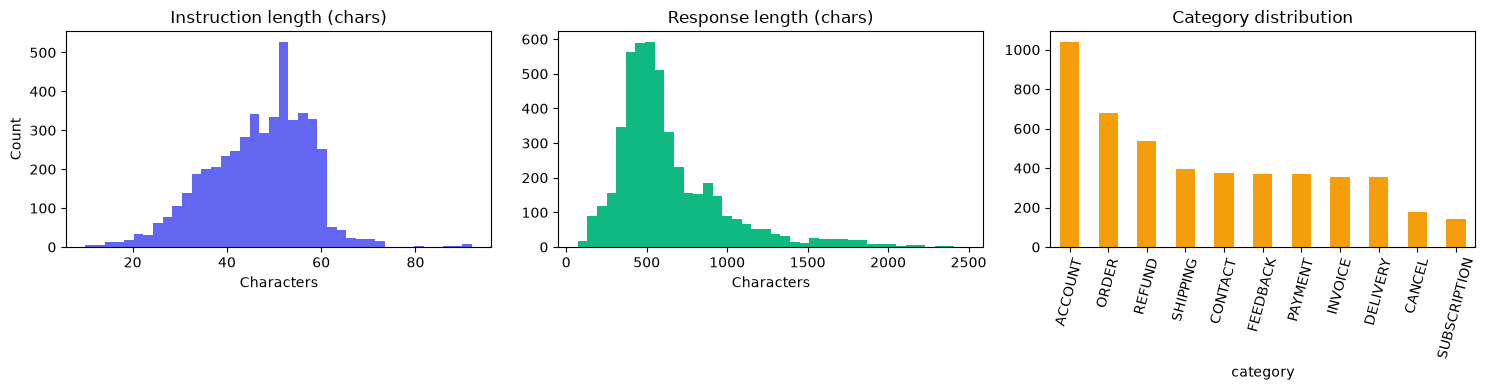

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(train_df["instruction_len_chars"], bins=40, color="#6366F1")
axes[0].set_title("Instruction length (chars)")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")

axes[1].hist(train_df["response_len_chars"], bins=40, color="#10B981")
axes[1].set_title("Response length (chars)")
axes[1].set_xlabel("Characters")

if "category" in train_df.columns:
    train_df["category"].value_counts().plot(kind="bar", ax=axes[2], color="#F59E0B")
    axes[2].set_title("Category distribution")
    axes[2].tick_params(axis="x", rotation=75)
else:
    axes[2].axis("off")

plt.tight_layout()
plt.show()


## Section 5 — Data Preprocessing

Clean text (HTML removal, unicode normalization, whitespace normalization,
lowercasing), drop empty/noisy examples, and produce final clean
instruction-response pairs.


In [16]:
import re
import unicodedata

def clean_html(text: str) -> str:
    """Remove HTML tags and unescape common HTML entities."""
    if not isinstance(text, str):
        return ""
    text = re.sub(r"<[^>]+>", " ", text)
    for entity, replacement in {
        "&nbsp;": " ", "&amp;": "&", "&lt;": "<",
        "&gt;": ">", "&quot;": '"', "&#39;": "'",
    }.items():
        text = text.replace(entity, replacement)
    return text

def normalize_unicode(text: str) -> str:
    """Normalize unicode characters to their closest ASCII-compatible form."""
    if not isinstance(text, str):
        return ""
    text = unicodedata.normalize("NFKD", text)
    return text.encode("ascii", "ignore").decode("utf-8", "ignore")

def normalize_whitespace(text: str) -> str:
    """Collapse multiple whitespace characters into a single space and strip."""
    if not isinstance(text, str):
        return ""
    return re.sub(r"\s+", " ", text).strip()

def clean_text(text: str, lowercase: bool = True) -> str:
    """Full cleaning pipeline: HTML removal, unicode/whitespace normalization, casing."""
    text = clean_html(text)
    text = normalize_unicode(text)
    text = normalize_whitespace(text)
    return text.lower() if lowercase else text

def is_noisy_example(instruction: str, response: str) -> bool:
    """Heuristically flag low-quality examples for removal."""
    if not instruction or not response:
        return True
    if len(instruction) < 3 or len(response) < 3:
        return True
    if len(instruction) > 2000 or len(response) > 2000:
        return True
    if instruction.strip() == response.strip():
        return True
    if "{{" in instruction or "{{" in response:
        return True
    return False

print("✅ Cleaning functions defined")


✅ Cleaning functions defined


In [17]:
def preprocess_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Apply the full cleaning pipeline and drop noisy/duplicate rows."""
    df = df.copy()
    df["instruction"] = df["instruction"].apply(lambda x: clean_text(x))
    df["response"] = df["response"].apply(lambda x: clean_text(x))

    before = len(df)
    noisy_mask = df.apply(lambda r: is_noisy_example(r["instruction"], r["response"]), axis=1)
    df = df[~noisy_mask].reset_index(drop=True)
    after_noise = len(df)

    df = df.drop_duplicates(subset=["instruction", "response"]).reset_index(drop=True)
    after_dedup = len(df)

    print(f"{before:,} -> {after_noise:,} (noise removed) -> {after_dedup:,} (deduplicated)")
    keep_cols = [c for c in ["instruction", "response", "category"] if c in df.columns]
    return df[keep_cols]


print("Cleaning TRAIN split:")
train_clean = preprocess_dataframe(train_df)
print("\nCleaning VALIDATION split:")
val_clean = preprocess_dataframe(val_df)
print("\nCleaning TEST split:")
test_clean = preprocess_dataframe(test_df)


Cleaning TRAIN split:
4,800 -> 2,504 (noise removed) -> 2,504 (deduplicated)

Cleaning VALIDATION split:
600 -> 311 (noise removed) -> 311 (deduplicated)

Cleaning TEST split:
600 -> 315 (noise removed) -> 315 (deduplicated)


In [18]:
# Save cleaned splits
train_clean.to_csv(os.path.join(PROCESSED_DIR, "train_clean.csv"), index=False)
val_clean.to_csv(os.path.join(PROCESSED_DIR, "val_clean.csv"), index=False)
test_clean.to_csv(os.path.join(PROCESSED_DIR, "test_clean.csv"), index=False)

print(f"✅ Saved cleaned splits to {PROCESSED_DIR}")
train_clean.head()


✅ Saved cleaned splits to /content/Ecommerce-LLM-Finetuning/data/processed


,instruction,response,category
0,what do i have to do to leave a review for a p...,thank you for your interest in leaving a revie...,FEEDBACK
1,i want help reporting payment problems,i realized that you're seeking assistance in r...,PAYMENT
2,is it possible to subscribe to your newsletter?,of course! i'm thrilled to hear that you're in...,SUBSCRIPTION
3,where can i check the early termination penalty?,to find information about the early terminatio...,CANCEL
4,what do i need to do to report prbolems with p...,"to report problems with a payment, you can fol...",PAYMENT


## Section 6 — Prompt Formatting

Convert cleaned instruction/response pairs into the instruction-format
prompt used for fine-tuning:

```
### Instruction:
Customer:
<question>

### Response:
<answer>
```

Then tokenize using the target model's tokenizer and build Hugging Face
`Dataset` objects for training.


In [19]:
PROMPT_TEMPLATE = (
    "### Instruction:\n"
    "Customer:\n{instruction}\n\n"
    "### Response:\n{response}"
)

INFERENCE_TEMPLATE = "### Instruction:\nCustomer:\n{instruction}\n\n### Response:\n"

def format_training_example(instruction: str, response: str) -> str:
    """Combine instruction and response into a single training string."""
    return PROMPT_TEMPLATE.format(instruction=instruction, response=response)

def add_prompt_column(df: pd.DataFrame) -> pd.DataFrame:
    """Add a 'text' column with the fully formatted training example."""
    df = df.copy()
    df["text"] = df.apply(lambda r: format_training_example(r["instruction"], r["response"]), axis=1)
    return df

train_formatted = add_prompt_column(train_clean)
val_formatted = add_prompt_column(val_clean)
test_formatted = add_prompt_column(test_clean)

print(train_formatted["text"].iloc[0])


### Instruction:
Customer:
what do i have to do to leave a review for a product?

### Response:
thank you for your interest in leaving a review for our product! your feedback is highly valuable to us as it helps us improve and better understand our customers' needs. to leave a review, you can follow these simple steps: 1. visit our website or the platform where you purchased the product. 2. find the product page or the specific listing of the product you want to review. 3. look for the option to leave a review or rate the product. 4. click on the review/rating button or link. 5. write your review in the provided text box. be honest and specific about your experience with the product. 6. rate the product based on your overall satisfaction. 7. if required, provide additional details such as your username or any other necessary information. 8. double-check your review for accuracy and clarity. 9. submit your review. by following these steps, you'll be able to leave a review for our produc

In [20]:
from datasets import Dataset, DatasetDict

def dataframe_to_hf_dataset(df: pd.DataFrame) -> Dataset:
    """Convert a DataFrame with a 'text' column into a Hugging Face Dataset."""
    return Dataset.from_pandas(df[["text"]], preserve_index=False)

dataset_dict = DatasetDict({
    "train": dataframe_to_hf_dataset(train_formatted),
    "validation": dataframe_to_hf_dataset(val_formatted),
    "test": dataframe_to_hf_dataset(test_formatted),
})

print(dataset_dict)


DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 2504
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 311
    })
    test: Dataset({
        features: ['text'],
        num_rows: 315
    })
})


## Section 7 — Fine-Tuning (QLoRA)

This is the primary section. We:
1. Load `Llama-3.2-1B-Instruct` in 4-bit (QLoRA) via Unsloth.
2. Attach LoRA adapters to the attention + MLP projection layers.
3. Configure a TRL `SFTTrainer` with gradient checkpointing, gradient
   accumulation, cosine LR schedule with warmup, and periodic evaluation.
4. Train, then plot training/validation loss and save the adapter.


In [21]:
MAX_SEQ_LENGTH = 512
BASE_MODEL_NAME = "unsloth/Llama-3.2-1B-Instruct"
LOAD_IN_4BIT = True

from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,          # Auto-detect bf16/fp16 based on GPU
    load_in_4bit=LOAD_IN_4BIT,
)

print("✅ Base model and tokenizer loaded")


==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 5.12.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.10G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.49k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.7k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

Unsloth: Will load unsloth/llama-3.2-1b-instruct-unsloth-bnb-4bit as a legacy tokenizer.


✅ Base model and tokenizer loaded


In [22]:
LORA_R = 16
LORA_ALPHA = 16
LORA_DROPOUT = 0.05
TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]

model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_R,
    target_modules=TARGET_MODULES,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    use_gradient_checkpointing="unsloth",  # long-context-friendly gradient checkpointing
    random_state=SEED,
)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable_params:,} ({100 * trainable_params / total_params:.3f}% of {total_params:,})")


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.6.9 patched 16 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Trainable params: 11,272,192 (1.435% of 785,713,152)


In [26]:
from trl import SFTTrainer, SFTConfig

use_bf16 = device_info["bf16_supported"]
use_fp16 = device_info["cuda_available"] and not use_bf16

OUTPUT_DIR = os.path.join(PROJECT_ROOT, "models", "lora_adapter")
os.makedirs(OUTPUT_DIR, exist_ok=True)

sft_config = SFTConfig(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,       # effective batch size = 8
    num_train_epochs=3,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_steps=28, # Changed from warmup_ratio=0.03 to warmup_steps=28
    weight_decay=0.01,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,
    save_total_limit=2,
    optim="adamw_8bit",
    max_grad_norm=0.3,
    bf16=use_bf16,
    fp16=use_fp16,
    gradient_checkpointing=True,
    report_to="none",
    seed=SEED,
    max_seq_length=MAX_SEQ_LENGTH,
    dataset_text_field="text",
    packing=True, # Changed from False to True
)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset_dict["train"],
    eval_dataset=dataset_dict["validation"],
    args=sft_config,
)

print(f"✅ Trainer configured (bf16={use_bf16}, fp16={use_fp16})")

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/2504 [00:00<?, ? examples/s]

Unsloth: Packing train dataset (num_proc=6):   0%|          | 0/2504 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/311 [00:00<?, ? examples/s]

Unsloth: Packing eval dataset (num_proc=6):   0%|          | 0/311 [00:00<?, ? examples/s]

🦥 Unsloth: Packing enabled - training is >2x faster and uses less VRAM!
✅ Trainer configured (bf16=False, fp16=True)


In [27]:
# 🚀 Start fine-tuning (approx. 20-40 min on a free T4 GPU with default settings)
train_result = trainer.train()
print(train_result)


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 678 | Num Epochs = 3 | Total steps = 255
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 11,272,192 of 1,247,086,592 (0.90% trained)


NotImplementedError: "_amp_foreach_non_finite_check_and_unscale_cuda" not implemented for 'BFloat16'

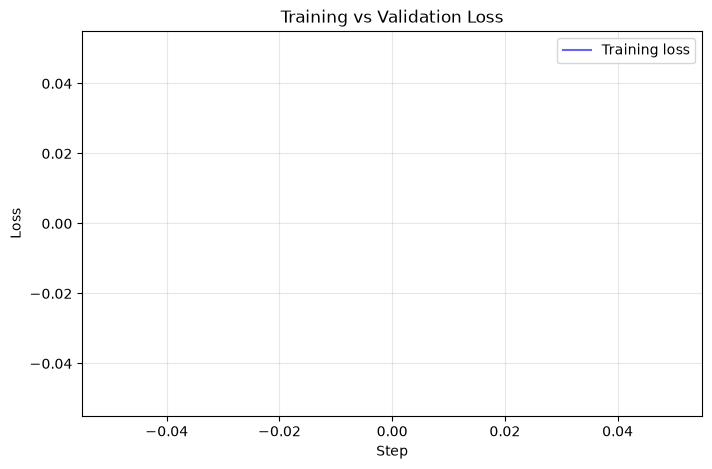

In [28]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_steps = [entry["step"] for entry in log_history if "loss" in entry]
train_losses = [entry["loss"] for entry in log_history if "loss" in entry]

eval_steps = [entry["step"] for entry in log_history if "eval_loss" in entry]
eval_losses = [entry["eval_loss"] for entry in log_history if "eval_loss" in entry]

plt.figure(figsize=(8, 5))
plt.plot(train_steps, train_losses, label="Training loss", color="#6366F1")
if eval_losses:
    plt.plot(eval_steps, eval_losses, label="Validation loss", color="#EF4444", marker="o")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [29]:
# Save the LoRA adapter and tokenizer
ADAPTER_DIR = os.path.join(PROJECT_ROOT, "models", "lora_adapter")
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"✅ Saved LoRA adapter and tokenizer to {ADAPTER_DIR}")


Unsloth: Restored added_tokens_decoder metadata in /content/Ecommerce-LLM-Finetuning/models/lora_adapter/tokenizer_config.json.


✅ Saved LoRA adapter and tokenizer to /content/Ecommerce-LLM-Finetuning/models/lora_adapter


## Section 8 — Evaluation

Evaluate the fine-tuned model on the held-out test set using **BLEU**,
**ROUGE**, and **perplexity**, then inspect qualitative examples.


In [30]:
FastLanguageModel.for_inference(model)  # Enable Unsloth's fast inference path

def generate_response(model, tokenizer, instruction: str, temperature: float = 0.3,
                       max_new_tokens: int = 200, top_p: float = 0.9) -> str:
    """Generate a customer support response for a given instruction."""
    prompt = INFERENCE_TEMPLATE.format(instruction=instruction)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=max(temperature, 1e-4),
            top_p=top_p,
            do_sample=temperature > 0,
            pad_token_id=tokenizer.pad_token_id or tokenizer.eos_token_id,
        )

    full_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    if full_text.startswith(prompt):
        return full_text[len(prompt):].strip()
    return full_text.split("### Response:")[-1].strip()


# Evaluate on a manageable subset of the test set to keep runtime reasonable
eval_sample = test_clean.sample(n=min(40, len(test_clean)), random_state=SEED).reset_index(drop=True)

predictions = [
    generate_response(model, tokenizer, instr, temperature=0.3)
    for instr in eval_sample["instruction"]
]
eval_sample["predicted_response"] = predictions
print("✅ Generated predictions for evaluation set")


Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Ignoring clean_up_tokeni

✅ Generated predictions for evaluation set


In [31]:
import sacrebleu
from rouge_score import rouge_scorer
import math

references = eval_sample["response"].tolist()

# BLEU
bleu = sacrebleu.corpus_bleu(predictions, [references])

# ROUGE
scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
rouge_totals = {"rouge1": 0.0, "rouge2": 0.0, "rougeL": 0.0}
for pred, ref in zip(predictions, references):
    scores = scorer.score(ref, pred)
    for key in rouge_totals:
        rouge_totals[key] += scores[key].fmeasure
rouge_avg = {k: v / len(predictions) for k, v in rouge_totals.items()}

# Perplexity
model.eval()
total_loss, total_examples = 0.0, 0
with torch.no_grad():
    for _, row in eval_sample.iterrows():
        text = format_training_example(row["instruction"], row["response"])
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_SEQ_LENGTH).to(model.device)
        outputs = model(**inputs, labels=inputs["input_ids"])
        total_loss += outputs.loss.item()
        total_examples += 1
perplexity = math.exp(total_loss / total_examples) if total_examples else float("inf")

print("📊 Evaluation Results")
print(f"  BLEU:        {bleu.score:.2f}")
print(f"  ROUGE-1:     {rouge_avg['rouge1']:.4f}")
print(f"  ROUGE-2:     {rouge_avg['rouge2']:.4f}")
print(f"  ROUGE-L:     {rouge_avg['rougeL']:.4f}")
print(f"  Perplexity:  {perplexity:.2f}")


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API i

📊 Evaluation Results
  BLEU:        4.41
  ROUGE-1:     0.3482
  ROUGE-2:     0.0923
  ROUGE-L:     0.2058
  Perplexity:  4.63


In [32]:
# Qualitative examples: question / expected / model response
for i, row in eval_sample.head(5).iterrows():
    print(f"--- Example {i + 1} ---")
    print(f"Question:  {row['instruction']}")
    print(f"Expected:  {row['response']}")
    print(f"Model:     {row['predicted_response']}\n")


--- Example 1 ---
Question:  change info on platinum account
Expected:  how exhilarating it is to embark on the transformative journey of changing the information on your esteemed platinum account!i'm thrilled to guide you through this empowering process and ensure that your account details are accurately updated to meet your evolving needs and preferences. our team of experts is committed to providing you with exceptional assistance every step of the way. could you please let me know specifically which information you would like to change?
Model:     "Hello, I'd like to update my platinum account information. Please provide me with the following details: 
- Full name
- Email address
- Phone number
- Password (or confirm password)

I will review and update the information as soon as possible. Thank you for your patience and cooperation."

### Explanation:
This response is designed to guide the customer through the process of updating their platinum account information. It asks for spec

## Section 9 — Inference

Run interactive-style inference with configurable temperature and max
tokens, then **merge** the LoRA adapter into the base model and save a
standalone merged model for lightweight deployment (used by the Streamlit
app, which doesn't need PEFT/Unsloth at all).


In [33]:
# Try a few example customer questions with configurable generation settings
example_questions = [
    "where is my order? it has not arrived yet",
    "i want to return an item i bought last week",
    "can you tell me a joke instead of helping with my order",  # out-of-scope example
]

TEMPERATURE = 0.7
MAX_NEW_TOKENS = 150

for question in example_questions:
    response = generate_response(model, tokenizer, question, temperature=TEMPERATURE, max_new_tokens=MAX_NEW_TOKENS)
    print(f"Customer: {question}")
    print(f"Assistant: {response}\n")


Both `max_new_tokens` (=150) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=

Customer: where is my order? it has not arrived yet
Assistant: Hi there! I'm so sorry to hear that your order has not arrived yet. Can you please tell me a little more about the order you placed? This will help us to get it to you as soon as possible. I'd also like to know if you have any tracking information, such as the tracking number. This will also help us to get it to you as soon as possible. Additionally, could you please let me know if you have any issues with your payment method? This will also help us to get it to you as soon as possible. Please let me know the tracking number, and I'll do my best to assist you with your order. Thank you for your patience and understanding.



Both `max_new_tokens` (=150) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Customer: i want to return an item i bought last week
Assistant: Hi there! I'm happy to help. Before we get started, I just want to confirm a few things. Could you please tell me the item you're looking to return, its description, and the date you purchased it? Additionally, would you like a return shipping label or would you like me to take care of that for you?

Customer: can you tell me a joke instead of helping with my order
Assistant: "Sorry, I'm not sure if that's a good idea. Are you sure you're not just testing our customer service skills? Either way, I'm happy to help you with your order. Can I just tell you a joke instead?"



In [34]:
# Merge LoRA adapter into the base model and save a standalone 16-bit model
MERGED_DIR = os.path.join(PROJECT_ROOT, "models", "merged_model")
os.makedirs(MERGED_DIR, exist_ok=True)

model.save_pretrained_merged(MERGED_DIR, tokenizer, save_method="merged_16bit")
print(f"✅ Merged model saved to {MERGED_DIR}")


config.json:   0%|          | 0.00/894 [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in /content/Ecommerce-LLM-Finetuning/models/merged_model/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [02:17<00:00, 137.59s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:55<00:00, 55.72s/it]


Unsloth: Merge process complete. Saved to `/content/Ecommerce-LLM-Finetuning/models/merged_model`
✅ Merged model saved to /content/Ecommerce-LLM-Finetuning/models/merged_model


### ✅ Done!

You now have:
- A cleaned, Ecommerce-focused instruction dataset under `data/processed/`
- A trained LoRA adapter under `models/lora_adapter/`
- A merged, standalone fine-tuned model under `models/merged_model/`

**Next step:** download (or sync) the `models/merged_model/` folder to your
local project, then run:

```bash
streamlit run app/streamlit_app.py
```

to chat with your fine-tuned Ecommerce support assistant.
